In [1]:
# Notebook 01 - Image Basics
# CamoDetect Project
# What is an image to a computer?

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

print("=" * 40)
print("CamoDetect - Week 1")
print("Libraries loaded successfully!")
print("=" * 40)

# Create a tiny 4x4 "fake" image manually
# Just numbers - no actual image file needed
tiny_image = torch.zeros(3, 4, 4)  # 3 channels, 4 rows, 4 cols

# Fill Red channel with 255 (full red)
tiny_image[0] = 255

print("\nShape of our image tensor:", tiny_image.shape)
print("\nWhat the RED channel looks like:")
print(tiny_image[0])
print("\nWhat the GREEN channel looks like:")
print(tiny_image[1])
print("\nWhat the BLUE channel looks like:")
print(tiny_image[2])

CamoDetect - Week 1
Libraries loaded successfully!

Shape of our image tensor: torch.Size([3, 4, 4])

What the RED channel looks like:
tensor([[255., 255., 255., 255.],
        [255., 255., 255., 255.],
        [255., 255., 255., 255.],
        [255., 255., 255., 255.]])

What the GREEN channel looks like:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])

What the BLUE channel looks like:
tensor([[0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.],
        [0., 0., 0., 0.]])


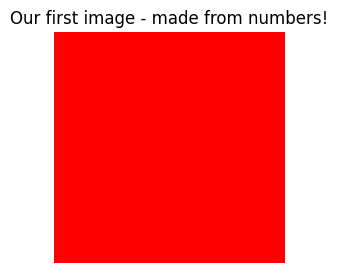

Every pixel is R=255, G=0, B=0 — pure red!


In [2]:
# Let's VISUALIZE the image we just created from numbers

# Matplotlib expects shape (height, width, channels) 
# Our tensor is (channels, height, width) so we need to rearrange
image_to_show = tiny_image.permute(1, 2, 0) / 255.0

plt.figure(figsize=(3, 3))
plt.imshow(image_to_show)
plt.title("Our first image - made from numbers!")
plt.axis('off')
plt.show()

print("Every pixel is R=255, G=0, B=0 — pure red!")

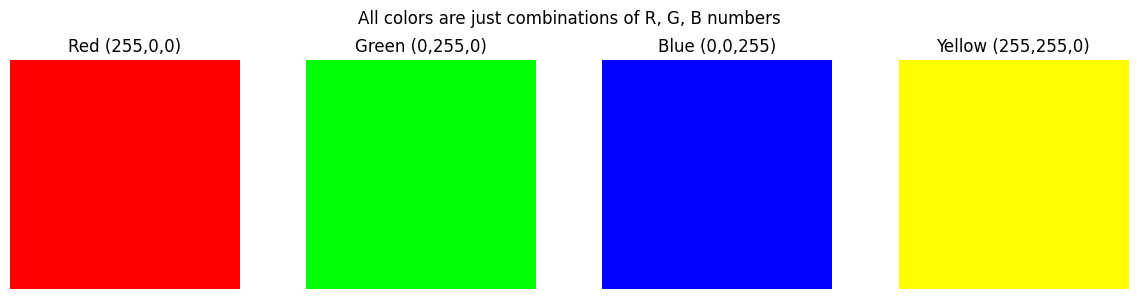

In [3]:
# What happens when we mix channels?
# Let's make 4 different colored squares and show them together

fig, axes = plt.subplots(1, 4, figsize=(12, 3))

# Pure Red
red = torch.zeros(3, 4, 4)
red[0] = 255

# Pure Green  
green = torch.zeros(3, 4, 4)
green[1] = 255

# Pure Blue
blue = torch.zeros(3, 4, 4)
blue[2] = 255

# Yellow (Red + Green mixed!)
yellow = torch.zeros(3, 4, 4)
yellow[0] = 255
yellow[1] = 255

colors = [red, green, blue, yellow]
names = ["Red (255,0,0)", "Green (0,255,0)", "Blue (0,0,255)", "Yellow (255,255,0)"]

for i, (img, name) in enumerate(zip(colors, names)):
    axes[i].imshow(img.permute(1, 2, 0) / 255.0)
    axes[i].set_title(name)
    axes[i].axis('off')

plt.suptitle("All colors are just combinations of R, G, B numbers", fontsize=12)
plt.tight_layout()
plt.show()

Image shape: torch.Size([3, 100, 100])
Min pixel value: 18.0
Max pixel value: 238.0


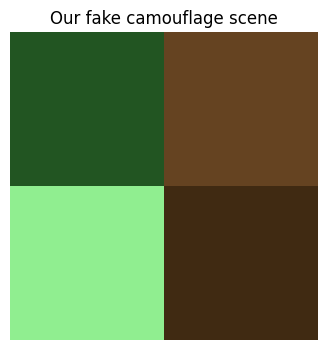

In [5]:
# Create our own test image - no internet needed!
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
import torch

# Create a 100x100 image with different colored regions
# This simulates what a camouflage scene might look like - patches of different colors
img_array = np.zeros((100, 100, 3), dtype=np.uint8)

# Top-left: dark green (like jungle)
img_array[0:50, 0:50] = [34, 85, 34]

# Top-right: brown (like mud/dirt)
img_array[0:50, 50:100] = [101, 67, 33]

# Bottom-left: light green (like grass)
img_array[50:100, 0:50] = [144, 238, 144]

# Bottom-right: dark brown (like shadow)
img_array[50:100, 50:100] = [64, 42, 18]

# Convert to PIL image
img = Image.fromarray(img_array)

# Convert to tensor
img_tensor = torch.tensor(img_array).permute(2, 0, 1).float()

print("Image shape:", img_tensor.shape)
print("Min pixel value:", img_tensor.min().item())
print("Max pixel value:", img_tensor.max().item())

# Show it
plt.figure(figsize=(4, 4))
plt.imshow(img_array)
plt.title("Our fake camouflage scene")
plt.axis('off')
plt.show()

In [6]:
# Let's inspect individual pixels - this is what our model will "see"

print("=== PIXEL INSPECTION ===\n")

# Pick a pixel from each region
pixels = {
    "Dark green (jungle) [0,0]":     img_tensor[:, 0, 0],
    "Brown (mud) [0,99]":            img_tensor[:, 0, 99],
    "Light green (grass) [99,0]":    img_tensor[:, 99, 0],
    "Dark brown (shadow) [99,99]":   img_tensor[:, 99, 99],
}

for location, pixel in pixels.items():
    r, g, b = pixel[0].item(), pixel[1].item(), pixel[2].item()
    print(f"{location}")
    print(f"  R={r:.0f}, G={g:.0f}, B={b:.0f}")
    print()

print("=== KEY INSIGHT ===")
print("Every pixel is just 3 numbers.")
print("CamoDetect's job: find the object whose")
print("numbers blend with the background numbers.")

=== PIXEL INSPECTION ===

Dark green (jungle) [0,0]
  R=34, G=85, B=34

Brown (mud) [0,99]
  R=101, G=67, B=33

Light green (grass) [99,0]
  R=144, G=238, B=144

Dark brown (shadow) [99,99]
  R=64, G=42, B=18

=== KEY INSIGHT ===
Every pixel is just 3 numbers.
CamoDetect's job: find the object whose
numbers blend with the background numbers.


In [8]:
# === WHAT DID WE LEARN TODAY? ===
# Write this in your own words as comments

# 1. Every image is just a collection of numbers...
# 2. Every collor is made up of three chanels R,G,B...
# 3. We can detect camouflaged thing not just a soldier by focusing on the pixels identical or closely related to the base pixel... 
# 4. The shape order in PyTorch is (Channels, Height, Width)...
# 5. CamoDetects job is to find camouflage thing in real time whit use of drone camaras and satalite images...

print("Week 1, Day 1 complete.")
print("Notebook saved to D:\\CamoDetect_Project\\01-image-basics.ipynb")

Week 1, Day 1 complete.
Notebook saved to D:\CamoDetect_Project\01-image-basics.ipynb


In [1]:
# LARA Preprocessing — the exact code that will run inside our API
# When a developer sends an image to LARA, this is step 1

import torch
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

# Simulate receiving an image (later this will come from the API request)
# We'll use our fake camouflage scene from before
img_array = np.zeros((100, 100, 3), dtype=np.uint8)
img_array[0:50, 0:50]   = [34, 85, 34]
img_array[0:50, 50:100] = [101, 67, 33]
img_array[50:100, 0:50] = [144, 238, 144]
img_array[50:100, 50:100] = [64, 42, 18]

# Step 1 — Convert to tensor
img_tensor = torch.tensor(img_array).permute(2, 0, 1).float()
print("Raw tensor shape:", img_tensor.shape)
print("Raw pixel range:", img_tensor.min().item(), "to", img_tensor.max().item())

# Step 2 — Normalize (this is what LARA will do to every image)
img_normalized = img_tensor / 255.0
print("\nAfter normalization:")
print("Normalized range:", img_normalized.min().item(), "to", img_normalized.max().item())

# Step 3 — Add batch dimension (models expect batches, not single images)
img_batch = img_normalized.unsqueeze(0)
print("\nAfter adding batch dimension:", img_batch.shape)
print("Shape means: (batch_size, channels, height, width)")
print("            (", img_batch.shape[0], ",", img_batch.shape[1], ",", img_batch.shape[2], ",", img_batch.shape[3], ")")

Raw tensor shape: torch.Size([3, 100, 100])
Raw pixel range: 18.0 to 238.0

After normalization:
Normalized range: 0.07058823853731155 to 0.9333333373069763

After adding batch dimension: torch.Size([1, 3, 100, 100])
Shape means: (batch_size, channels, height, width)
            ( 1 , 3 , 100 , 100 )


In [2]:
# Simulate what a detection model returns
# In Week 3 we'll use a real model — for now we fake the output
# to understand the data structure

def fake_model_inference(img_batch):
    # A real model returns bounding boxes + labels + confidence scores
    # Format: [x1, y1, x2, y2, confidence, class_id]
    fake_detections = [
        {"label": "person",   "confidence": 0.92, "box": [10, 10, 45, 80]},
        {"label": "vehicle",  "confidence": 0.76, "box": [55, 20, 95, 60]},
    ]
    return fake_detections

# Run inference
detections = fake_model_inference(img_batch)

# Postprocess — format into clean JSON (exactly what LARA returns to developer)
import json

api_response = {
    "status": "success",
    "model": "lara-detect-v1",
    "image_size": [img_batch.shape[2], img_batch.shape[3]],
    "detections": detections,
    "count": len(detections)
}

print("LARA API Response:")
print(json.dumps(api_response, indent=2))

LARA API Response:
{
  "status": "success",
  "model": "lara-detect-v1",
  "image_size": [
    100,
    100
  ],
  "detections": [
    {
      "label": "person",
      "confidence": 0.92,
      "box": [
        10,
        10,
        45,
        80
      ]
    },
    {
      "label": "vehicle",
      "confidence": 0.76,
      "box": [
        55,
        20,
        95,
        60
      ]
    }
  ],
  "count": 2
}


In [3]:
# ============================================
# WEEK 1 COMPLETE — LARA Foundation
# ============================================
# What I built today:
# 1. Image → tensor conversion
# 2. Normalization (0-255 → 0-1)
# 3. Batch dimension (model-ready format)
# 4. Full API response structure

print("Week 1 complete.")
print("LARA preprocessing pipeline: DONE")
print("LARA response format: DONE")
print("Next: FastAPI — building the actual API endpoint")

Week 1 complete.
LARA preprocessing pipeline: DONE
LARA response format: DONE
Next: FastAPI — building the actual API endpoint
